<a href="https://colab.research.google.com/github/miaflynn/CYPLAN255-Final-Project/blob/main/03c_visualizations_net_change.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importing

In [206]:

import pandas as pd
import geopandas as gpd
import numpy as np
import os
%matplotlib inline
import matplotlib.pyplot as plt
from shapely.geometry import LineString
import plotly.express as px
import seaborn as sns


from google.colab import drive
drive.mount('/content/drive')


#uncomment on first run
# !wget https://raw.githubusercontent.com/miaflynn/CYPLAN255-Final-Project/main/functions.py
# import functions as fx

import importlib
importlib.reload(fx)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<module 'functions' from '/content/functions.py'>

##Reading in file

In [207]:
#gdf of opening dates after 2016 concatenated with gdf of closing dates after 2016
gdf_open_close = gpd.read_file("/content/drive/MyDrive/C255_final_project/cleaned/open_close_after_2016.geojson")

#all businesses with no end date or end dates after 2016
gdf_biz = gpd.read_file("/content/drive/MyDrive/C255_final_project/cleaned/biz_all_startdate.geojson")

#immediately clipping to exclude openings in 2026
gdf_biz = gdf_biz[(gdf_biz.year_open <=2025)]

##Reading in census tracts and block groups

In [208]:
sf_tracts = gpd.read_file('/content/drive/MyDrive/C255_final_project/cleaned/sf_tracts.geojson')

sf_block_grp = gpd.read_file('/content/drive/MyDrive/C255_final_project/cleaned/sf_block_grp.geojson')

##Do i want to filter to a specific naics code or collection of codes?

In [233]:
naics_dict = {

    'Information': '5100-5199',
    'Financial Services': '5210-5239',
    'Accommodations': '7210-7219',
    'Retail Trade': '4400-4599',
    'Construction': '2300-2399',
    'Food Services': '7220-7229',
    'Manufacturing': '3100-3399',
    'Real Estate and Rental and Leasing Services': '5300-5399',
    'Arts, Entertainment, and Recreation': '7100-7199',
    'Private Education and Health Services': '6100-6299',
    'Administrative and Support Services': '5600-5699',
    'Professional, Scientific, and Technical Services': '5400-5499',
    'Certain Services': '8100-8139',
    'Wholesale Trade': '4200-4299',
    'Transportation and Warehousing': '4800-4999',
    'Insurance': '5240-5249',
    'Utilities': '2200-2299',

    #special categories
    'Retail, Food and Arts/Entertainment':'7220-7229|4400-4599|7100-7199'

}

#------------------------Desired cateogry--------------------------
naics_name = 'all'
naics_name = 'Food Services'
#------------------------------------------------------------------


In [210]:
open_close_tracts_gdf = fx.calc_business_dynamics(
    gdf_open_close,
    gdf_biz,
    sf_tracts,
    naics_name
)

open_close_grp_gdf = fx.calc_business_dynamics(
    gdf_open_close,
    gdf_biz,
    sf_block_grp,
    naics_name
)

In [211]:
open_close_tracts_gdf

,GEOID,geometry,year,closed,opened,naics_filter,net_change,baseline_2016,growth_pct_over_2016,biz_stock,net_entry_rate,gross_exit_rate,total_activity
0,06075060400,"POLYGON ((-122.5068 37.73556, -122.50614 37.73...",2016.0,0.0,2.0,Food Services,2.0,2.0,100.0,3,66.666667,66.666667,2.0
1,06075060400,"POLYGON ((-122.5068 37.73556, -122.50614 37.73...",2019.0,1.0,1.0,Food Services,0.0,2.0,0.0,4,0.000000,25.000000,2.0
2,06075060400,"POLYGON ((-122.5068 37.73556, -122.50614 37.73...",2021.0,0.0,2.0,Food Services,2.0,2.0,100.0,5,40.000000,40.000000,2.0
3,06075035400,"POLYGON ((-122.50846 37.74892, -122.50794 37.7...",2016.0,2.0,4.0,Food Services,2.0,2.0,100.0,11,18.181818,36.363636,6.0
4,06075035400,"POLYGON ((-122.50846 37.74892, -122.50794 37.7...",2017.0,2.0,5.0,Food Services,3.0,2.0,150.0,14,21.428571,35.714286,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1760,06075010101,"POLYGON ((-122.41586 37.80869, -122.41266 37.8...",2021.0,7.0,10.0,Food Services,3.0,8.0,37.5,60,5.000000,16.666667,17.0
1761,06075010101,"POLYGON ((-122.41586 37.80869, -122.41266 37.8...",2022.0,7.0,3.0,Food Services,-4.0,8.0,-50.0,56,-7.142857,5.357143,10.0
1762,06075010101,"POLYGON ((-122.41586 37.80869, -122.41266 37.8...",2023.0,5.0,8.0,Food Services,3.0,8.0,37.5,57,5.263158,14.035088,13.0
1763,06075010101,"POLYGON ((-122.41586 37.80869, -122.41266 37.8...",2024.0,6.0,8.0,Food Services,2.0,8.0,25.0,60,3.333333,13.333333,14.0


##getting epc tracts and adding is_epc boolean

In [212]:
epc_tracts = gpd.read_file("/content/drive/MyDrive/C255_final_project/cleaned/epc_tracts_sf.geojson")
epc_tracts = epc_tracts.rename(columns={'tract_geoid': 'GEOID'})

open_close_tracts_gdf['is_epc'] = open_close_tracts_gdf['GEOID'].isin(epc_tracts['GEOID'])

#Choropleth maps

###Net entry rate map (net change for year / total businesses active that year)

In [213]:
#commenting out for github

# #block grp
# fx.choropleth_animated(
#     open_close_grp_gdf, 'net_entry_rate', epc_tracts
# )

# #tract level
# fx.choropleth_animated(
#     open_close_tracts_gdf, 'net_entry_rate', epc_tracts
# )


###Map of percent change in businesses compared to 2016 (net change each year / baseline net change in 2016)

In [214]:
# #block group
# fx.choropleth_animated(
#     open_close_grp_gdf, 'growth_pct_over_2016', epc_tracts, 2017
# )

# #tract level
# fx.choropleth_animated(
#     open_close_tracts_gdf, 'growth_pct_over_2016', epc_tracts, 2017
# )

#EPC Line Graph

Text(0.5, 1.0, 'Net entry rate of Food Services businesses in EPC and non-EPC tracts')

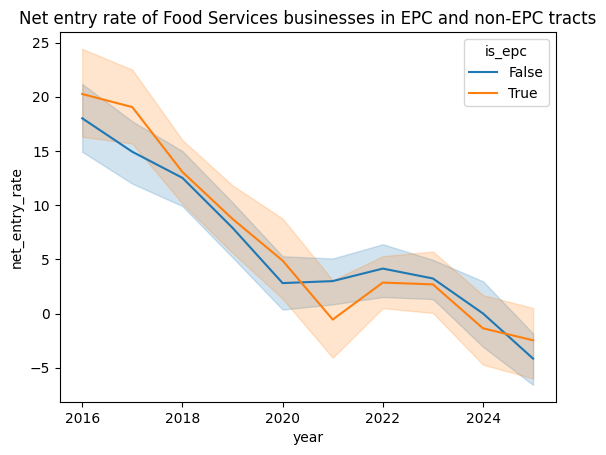

In [224]:
sns.lineplot(
    open_close_tracts_gdf,
    x='year',
    y='net_entry_rate',
    hue='is_epc',
    estimator='mean'
)

plt.title(f'Net entry rate of {naics_name} businesses in EPC and non-EPC tracts')


#Across industries line graph

In [243]:
#looking at naics keys real quick
gdf_biz['naics_code_description'].value_counts()

,count
naics_code_description,
Real Estate and Rental and Leasing Services,24394
"Professional, Scientific, and Technical Services",22342
Food Services,12415
Retail Trade,11899
Private Education and Health Services,8445
"Arts, Entertainment, and Recreation",7833
Accommodations,7652
Construction,6957
Multiple,4626


In [244]:
#naics code names to compare - top ten types of businesses
naics_to_compare = ['Food Services',
                    'Retail Trade',
                    'Arts, Entertainment, and Recreation',
                    'Accommodations',
                    'Financial Services',
                    'Private Education and Health Services',
                    'Professional, Scientific, and Technical Services',
                    'Real Estate and Rental and Leasing Services',
                    'Construction',
                    'Financial Services'
]

dfs = []
for name in naics_to_compare:
    result = fx.calc_business_dynamics(gdf_open_close, gdf_biz, sf_tracts, naics_name=name)
    result['naics_name'] = name
    dfs.append(result)

combined = pd.concat(dfs)

#look here to see metric options
combined.columns

Index(['GEOID', 'geometry', 'year', 'closed', 'opened', 'naics_filter',
       'net_change', 'baseline_2016', 'growth_pct_over_2016', 'biz_stock',
       'net_entry_rate', 'gross_exit_rate', 'total_activity', 'naics_name'],
      dtype='object')

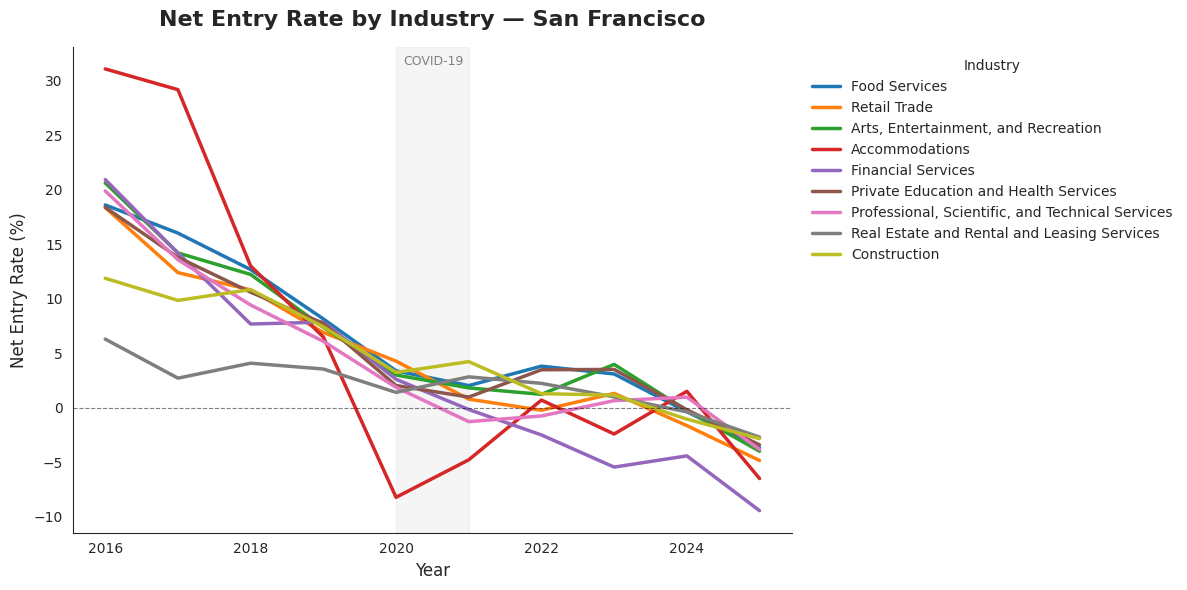

In [245]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.set_style('white')
sns.lineplot(
    combined,
    x='year',
    y='net_entry_rate',
    hue='naics_name',
    errorbar=None,
    estimator='mean',
    linewidth=2.5,
    ax=ax
)

# add a horizontal line at 0
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

# clean up axes
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Net Entry Rate (%)', fontsize=12)
ax.set_title('Net Entry Rate by Industry — San Francisco', fontsize=16, fontweight='bold', pad=15)

# move legend outside
ax.legend(title='Industry', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)

# shade covid period
ax.axvspan(2020, 2021, alpha=0.08, color='gray', label='COVID-19')
ax.text(2020.1, ax.get_ylim()[1] * 0.95, 'COVID-19', fontsize=9, color='gray')

sns.despine()
plt.tight_layout()
plt.show()